In [5]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.ndimage import median_filter
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import generic_filter
from scipy.stats import binned_statistic_2d
import os
import re
from datetime import datetime

In [6]:
auth = earthaccess.login(persist=True)

### Do not change tspan. NEUROST timing index is wrong

In [7]:
tspan = ("2023-01-01", "2023-01-30")

### Select your time range below:

In [8]:
t1 = datetime(2024,6,1)
t2 = datetime(2024,6,1)

In [9]:
results = earthaccess.search_data(
    short_name="NEUROST_SSH-SST_L4_V2024.0",
    temporal=tspan)

In [10]:
paths = earthaccess.open(results) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/532 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/532 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/532 [00:00<?, ?it/s]

In [11]:
# parse only the FIRST date (analysis date)

#account for issues in NEUROST indexing
fname_pattern = re.compile(r"NeurOST_SSH-SST_(\d{8})_\d{8}\.nc", re.IGNORECASE)

def extract_analysis_date(fname):
    m = fname_pattern.search(fname)
    if not m:
        return None
    return datetime.strptime(m.group(1), "%Y%m%d")

filtered = []
for obj in paths:
    s = str(obj)

    # extract filename from repr
    m = fname_pattern.search(s)
    if not m:
        continue

    date = datetime.strptime(m.group(1), "%Y%m%d")

    if t1 <= date <= t2:
        filtered.append(obj)

print("Matched:", len(filtered), "files")

Matched: 1 files


In [12]:
dataset = xr.open_dataset(filtered[0]) #for netcdf

### If you want to crop:

In [17]:
bbox = (360-73, 34, 360-70, 37.5) #edward

In [18]:
mask = (dataset.longitude >= bbox[0]) & (dataset.longitude <= bbox[2]) & (dataset.latitude >= bbox[1]) & (dataset.latitude <= bbox[3])
if mask.sum() == 0:
    mask = (dataset.longitude >= bbox[0]) & (dataset.longitude <= bbox[2])
    if mask.sum() == 0:
        print('Mask via longitude only')
        mask = (dataset.latitude >= bbox[1]) & (dataset.latitude <= bbox[3])
        print(mask.sum())
    else:
        print('Mask via latitude only')

In [19]:
dataset_cropped = dataset.where(mask, drop=True)

In [20]:
dataset_cropped

<xarray.Dataset> Size: 38kB
Dimensions:                 (latitude: 35, longitude: 30, time: 1)
Coordinates:
  * longitude               (longitude) float64 240B 287.1 287.2 ... 289.9 290.0
  * latitude                (latitude) float64 280B 34.1 34.2 34.3 ... 37.4 37.5
  * time                    (time) datetime64[ns] 8B 2024-06-01
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Data variables:
    sla                     (latitude, longitude, time) float32 4kB 0.1243 .....
    adt                     (latitude, longitude, time) float32 4kB 0.85 ... ...
    ugosa                   (latitude, longitude, time) float32 4kB -0.1668 ....
    vgosa                   (latitude, longitude, time) float32 4kB 0.1145 .....
    sn                      (latitude, longitude, time) float32 4kB 8.036e-06...
    ss                      (latitude, longitude, time) float32 4kB 3.978e-06...
    zeta                    (latitude, longitude, time) float32 4kB 3.54e-06 ...
    ugos                    (latitude, longitude, time) float32 4kB -0.2564 ....
    vgos                    (latitude, longitude, time) float32 4kB 0.08849 ....
Attributes: (12/37)
    title:                      Daily NeurOST (SSH-SST) Sea Surface Height an...
    summary:                    A mapped level 4 sea surface height analysis ...
    Conventions:                CF-1.10
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    keywords:                   Oceans > Sea Surface Topography > Sea Surface...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    ...                         ...
    creator_url:                http://podaac.jpl.nasa.gov
    publisher_name:             JPL PO.DAAC
    publisher_url:              http://podaac.jpl.nasa.gov
    date_created:               2024-11-26T14:33:55.633872
    references:                 https://doi.org/10.31223/X5W676 and https://d...
    comment:                    NeurOST = Neural Ocean Surface Topography. Ne...

Text(0.5, 1.0, '2024-06-01 00:00:00')

<Figure size 640x480 with 0 Axes>

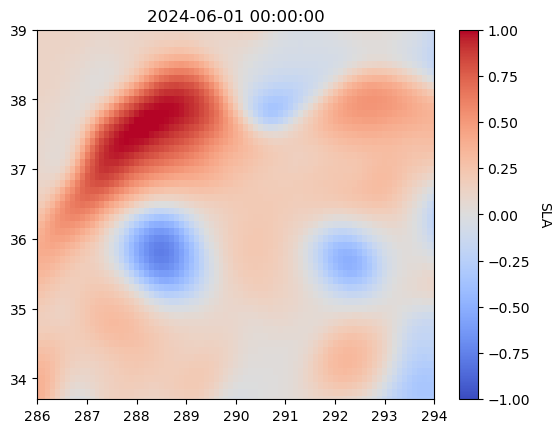

In [26]:
plt.clf()

fig,ax=plt.subplots()

plot = ax.pcolormesh(dataset.longitude,dataset.latitude,np.squeeze(dataset.sla),cmap='coolwarm',vmin=-1,vmax=1)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('SLA', rotation=270, labelpad=15)

ax.set_xlim([286,294])
ax.set_ylim([33.7,39])
ax.set_title(t1)